# IAM Handwriting CRNN

## 1. Objective
Improve the current IAM CRNN project so it generalizes better to handwriting from different users, while keeping the currently working project safe.

## 3. Configuration

## 2. Imports


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import editdistance
from tensorflow.keras import layers
from tensorflow.keras import callbacks




In [2]:
RANDOM_SEED = 42

IMAGE_WIDTH = 128
IMAGE_HEIGHT = 32
MAX_SEQ_LENGTH = 32

BATCH_SIZE = 128

USE_ONLY_OK = True
BLANK_INDEX = 0

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

import random
random.seed(RANDOM_SEED)


## 4. Dataset Loading

In [3]:
form_txt_path = "../data/IAM/form.txt"
form_to_writer = {}
with open(form_txt_path, "r") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split(" ")
        if len(parts) >= 2:
            form_to_writer[parts[0]] = parts[1]

words_txt_path = "../data/IAM/words.txt"
dataset = []
with open(words_txt_path, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.rstrip("\n").split(" ", 8)
        if USE_ONLY_OK and parts[1] != "ok":
            continue
        word_id = parts[0]
        
        # Original writer mapping using form.txt
        form_id = "-".join(word_id.split("-")[:2])
        writer_id = form_to_writer.get(form_id, "UNKNOWN")
        
        if len(parts) < 9:
            continue
            
        transcription = parts[8]
        if not transcription or len(transcription) > MAX_SEQ_LENGTH:
            continue
        dataset.append({
            "word_id": word_id,
            "writer_id": writer_id,
            "transcription": transcription
        })
dataset_df = pd.DataFrame(dataset)


## 5. EDA

In [4]:
print(f"Total dataset size before validation: {len(dataset_df)}")
print(f"Unique writers: {dataset_df['writer_id'].nunique()}")
print(dataset_df.head())


Total dataset size before validation: 96456
Unique writers: 657
          word_id writer_id transcription
0  a01-000u-00-00       000             A
1  a01-000u-00-01       000          MOVE
2  a01-000u-00-02       000            to
3  a01-000u-00-03       000          stop
4  a01-000u-00-04       000           Mr.


### Image Validation / Invalid Samples

In [5]:
def validate_image_path(word_id):
    parts = word_id.split("-")
    img_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{word_id}.png"
    if not os.path.exists(img_path) or os.path.getsize(img_path) == 0:
        return False
    return True

dataset_df['is_valid'] = dataset_df['word_id'].apply(validate_image_path)
invalid_count = len(dataset_df[~dataset_df['is_valid']])
print(f"Found {invalid_count} missing or empty image files.")
dataset_df = dataset_df[dataset_df['is_valid']].copy()
print(f"Final valid samples: {len(dataset_df)}")

# Explicit assertions for Baseline Consistency
assert len(dataset_df) == 96454, f"Valid sample count must be exactly 96454, got {len(dataset_df)}"
assert dataset_df['writer_id'].nunique() == 657, f"Unique writers must be exactly 657, got {dataset_df['writer_id'].nunique()}"
assert "UNKNOWN" not in dataset_df['writer_id'].values, "There must be no UNKNOWN writer IDs"
print("Baseline Dataset Consistency Check: PASSED")


Found 2 missing or empty image files.
Final valid samples: 96454
Baseline Dataset Consistency Check: PASSED


### Representative Images

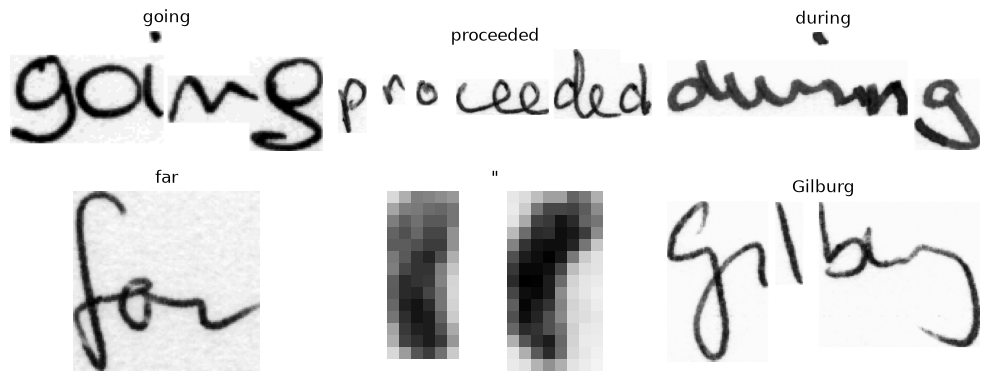

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 4))
sample_df = dataset_df.sample(6, random_state=RANDOM_SEED)
for i, (idx, row) in enumerate(sample_df.iterrows()):
    ax = axes[i//3, i%3]
    parts = row['word_id'].split("-")
    img_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{row['word_id']}.png"
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        ax.imshow(img, cmap='gray')
    ax.set_title(row['transcription'])
    ax.axis('off')
plt.tight_layout()
# plt.show()


## 6. Writer-Aware Train/Validation/Test Split

In [7]:
writers = dataset_df['writer_id'].unique().to_numpy().copy()
np.random.shuffle(writers)

train_size = int(len(writers) * 0.8)
val_size = int(len(writers) * 0.1)

train_writers = set(writers[:train_size])
val_writers = set(writers[train_size:train_size + val_size])
test_writers = set(writers[train_size + val_size:])

train_df = dataset_df[dataset_df['writer_id'].isin(train_writers)].copy()
val_df = dataset_df[dataset_df['writer_id'].isin(val_writers)].copy()
test_df = dataset_df[dataset_df['writer_id'].isin(test_writers)].copy()

assert len(train_writers.intersection(val_writers)) == 0
assert len(train_writers.intersection(test_writers)) == 0

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

iam_vocab = [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

char_to_num = tf.keras.layers.StringLookup(vocabulary=iam_vocab, mask_token=None)
num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)

NUM_CLASSES = char_to_num.vocabulary_size()
assert len(iam_vocab) == 79
assert NUM_CLASSES == 80
BLANK_INDEX = 0


Train samples: 78534
Validation samples: 8412
Test samples: 9508


## 8. Image Preprocessing

In [8]:
def process_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.resize_with_pad(img, target_height=IMAGE_HEIGHT, target_width=IMAGE_WIDTH)
    img = tf.transpose(img, perm=[1, 0, 2])
    return img

def encode_single_sample(word_id, transcription):
    word_id_str = word_id.numpy().decode("utf-8")
    text = transcription.numpy().decode("utf-8")
    parts = word_id_str.split("-")
    image_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{word_id_str}.png"
    
    img = process_image(image_path)
    
    label_tensor = char_to_num(tf.constant(list(text), dtype=tf.string))
    label = label_tensor.numpy().astype(np.int32).tolist()
    
    label_len = len(label)
    pad_len = MAX_SEQ_LENGTH - label_len
    padded_label = label + [BLANK_INDEX] * pad_len
    y_true_extended = padded_label + [label_len]
    
    return img, y_true_extended


### TensorFlow Dataset Pipeline

In [9]:
def create_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["word_id"].values,
        dataframe["transcription"].values
    ))
    dataset = dataset.map(
        lambda w, t: tf.py_function(encode_single_sample, [w, t], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda img, label_ext: (
            tf.ensure_shape(img, [IMAGE_WIDTH, IMAGE_HEIGHT, 1]),
            tf.ensure_shape(label_ext, [MAX_SEQ_LENGTH + 1])
        )
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)


## 9. CRNN Architecture

The baseline CRNN architecture is restored directly from the serialized checkpoint `../models/iam_crnn_best.keras`.


In [10]:
# Load the complete saved model directly
baseline_model = tf.keras.models.load_model("../models/iam_crnn_best.keras", compile=False)


### Model Summary

In [11]:
# The actual loaded model must show:
# input shape (None, 128, 32, 1)
# output shape (None, 32, 80)
# parameter count 530,832
baseline_model.summary()


Model: "crnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 8, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32, 64)         │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 32, 80)         │        10,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,832 (2.02 MB)

 Trainable params: 530,704 (2.02 MB)

 Non-trainable params: 128 (512.00 B)

## 10. CTC Loss

In [12]:
def ctc_loss(y_true_extended, y_pred):
    y_true = tf.cast(y_true_extended[:, :-1], tf.int32)
    label_length = tf.cast(y_true_extended[:, -1], tf.int32)
    
    batch_size = tf.shape(y_pred)[0]
    logit_length = tf.fill([batch_size], tf.shape(y_pred)[1])
    
    loss = tf.nn.ctc_loss(
        labels=y_true,
        logits=y_pred,
        label_length=label_length,
        logit_length=logit_length,
        logits_time_major=False,
        blank_index=BLANK_INDEX
    )
    return tf.reduce_mean(loss)

def decode_batch(predictions):
    input_len = np.ones(predictions.shape[0]) * predictions.shape[1]
    results = tf.keras.backend.ctc_decode(predictions, input_length=input_len, greedy=True)[0][0]
    
    output_text = []
    for res in results:
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        res = res.replace('[UNK]', '').strip()
        output_text.append(res)
    return output_text


## 12. Baseline Training

In [13]:
# epochs = 50
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
# checkpoint = tf.keras.callbacks.ModelCheckpoint("../models/iam_crnn_best.keras", monitor="val_loss", save_best_only=True)
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)


### Baseline Model Compilation


In [13]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=ctc_loss
)
print("Baseline model compiled.")


Baseline model compiled.


## 13. Baseline Evaluation

In [14]:
def evaluate_model(model, dataset):
    total_words = 0
    correct_words = 0
    total_cer = 0.0
    total_wer = 0.0
    
    import editdistance
    
    for batch_images, batch_labels in dataset:
        preds = model.predict(batch_images, verbose=0)
        pred_texts = decode_batch(preds)
        
        real_labels = batch_labels[:, :-1]
        label_lengths = batch_labels[:, -1]
        
        for i in range(len(pred_texts)):
            pred = pred_texts[i]
            length = int(label_lengths[i].numpy())
            true_indices = real_labels[i][:length]
            true_str = tf.strings.reduce_join(num_to_char(true_indices)).numpy().decode("utf-8")
            
            total_words += 1
            if pred == true_str:
                correct_words += 1
                
            total_cer += editdistance.eval(pred, true_str) / max(len(true_str), 1)
            total_wer += int(pred != true_str)
            
    return {
        "word_accuracy": correct_words / max(total_words, 1),
        "cer": total_cer / max(total_words, 1),
        "wer": total_wer / max(total_words, 1)
    }

baseline_results = evaluate_model(baseline_model, test_ds)
print(f"Baseline Word Accuracy: {baseline_results['word_accuracy']:.2%}")
print(f"Baseline CER: {baseline_results['cer']:.4f}")
print(f"Baseline WER: {baseline_results['wer']:.4f}")


Baseline Word Accuracy: 63.04%
Baseline CER: 0.1261
Baseline WER: 0.3696


## 14. Baseline Error Analysis

In [15]:
def display_error_analysis(model, dataset, num_samples=10):
    import matplotlib.pyplot as plt

    real_labels = None
    label_lengths = None

    count = 0
    fig, axes = plt.subplots(
        (num_samples + 1) // 2,
        2,
        figsize=(15, num_samples * 1.5)
    )
    axes = np.array(axes).flatten()

    for batch_images, batch_labels in dataset:
        preds = model.predict(batch_images, verbose=0)
        pred_texts = decode_batch(preds)

        real_labels = batch_labels[:, :-1]
        label_lengths = batch_labels[:, -1]

        for i in range(len(pred_texts)):
            pred = pred_texts[i]

            length = int(label_lengths[i].numpy())
            true_indices = real_labels[i][:length]

            true_str = tf.strings.reduce_join(
                num_to_char(true_indices)
            ).numpy().decode("utf-8")

            if pred != true_str:
                ax = axes[count]

                img = (batch_images[i].numpy() * 255).astype(np.uint8)
                img = np.transpose(img, (1, 0, 2))

                ax.imshow(
                    img,
                    cmap="gray",
                    vmin=0,
                    vmax=255
                )

                ax.set_title(
                    f"Ground Truth: {true_str}\n"
                    f"Prediction: {pred}\n"
                    f"CORRECT / ERROR: ERROR"
                )
                ax.axis("off")

                count += 1

                if count >= num_samples:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()

Baseline Example Predictions:


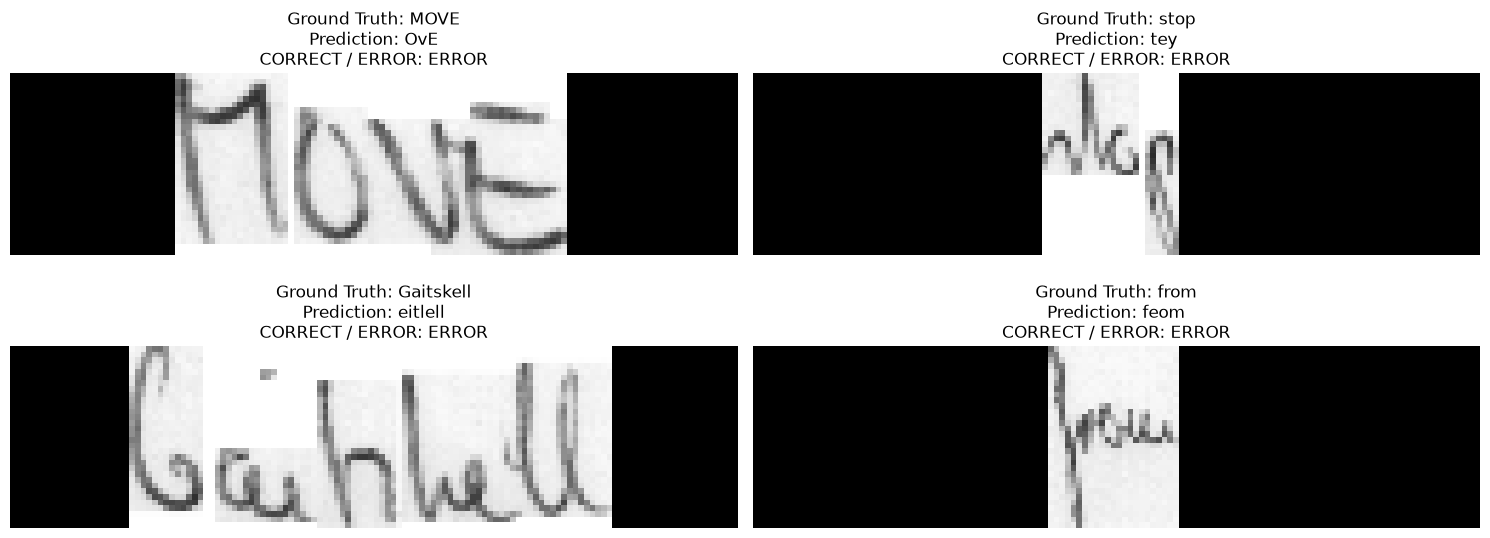

In [16]:
print("Baseline Example Predictions:")
display_error_analysis(baseline_model, test_ds, num_samples=4)


## 15. Fine-Tuning Experiment 1

Spatial augmentations are applied *before* `resize_with_pad()` on the original normalized image. We use `fill_value=1.0` (white) because the unpadded IAM paper background is white (~1.0). Only *after* spatial augmentations do we apply `resize_with_pad()`, which adds straight black padding bars (`0.0`).

### Augmentation Configuration

In [30]:
rotation_layer = tf.keras.layers.RandomRotation(factor=3.0/360.0, fill_mode="constant", fill_value=1.0)
translation_layer = tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="constant", fill_value=1.0)
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode="constant", fill_value=1.0)

def augment_image(image):
    # Spatial augmentations before resize_with_pad, assuming white background (1.0)
    img = rotation_layer(image)
    img = translation_layer(img)
    img = zoom_layer(img)
    
    # Brightness/Contrast
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    
    return img

def process_image_augmented_path(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.cast(image, tf.float32) / 255.0
    
    image = augment_image(image)
    
    image = tf.image.resize_with_pad(image, IMAGE_HEIGHT, IMAGE_WIDTH)
    image = tf.transpose(image, perm=[1, 0, 2])
    return image

def encode_single_sample_augmented(word_id, transcription):
    word_id_str = word_id.numpy().decode("utf-8")
    text = transcription.numpy().decode("utf-8")
    parts = word_id_str.split("-")
    image_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{word_id_str}.png"
    
    img = process_image_augmented_path(image_path)
    
    label_tensor = char_to_num(tf.constant(list(text), dtype=tf.string))
    label = label_tensor.numpy().astype(np.int32).tolist()
    
    label_len = len(label)
    pad_len = MAX_SEQ_LENGTH - label_len
    padded_label = label + [BLANK_INDEX] * pad_len
    y_true_extended = padded_label + [label_len]
    
    return img, y_true_extended

def create_dataset_augmented(dataframe):

    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["word_id"].values,
        dataframe["transcription"].values
    ))

    dataset = dataset.map(
        lambda w, t: tf.py_function(
            encode_single_sample_augmented,
            [w, t],
            [tf.float32, tf.int32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.map(
        lambda img, label_ext: (
            tf.ensure_shape(img, [IMAGE_WIDTH, IMAGE_HEIGHT, 1]),
            tf.ensure_shape(label_ext, [MAX_SEQ_LENGTH + 1])
        )
    )

    return (
        dataset
        .batch(BATCH_SIZE)
        .repeat()
        .prefetch(tf.data.AUTOTUNE)
    )

train_ds_aug = create_dataset_augmented(train_df)


In [31]:
print("Train dataset batches:")
print(tf.data.experimental.cardinality(train_ds).numpy())

print("Augmented dataset batches:")
print(tf.data.experimental.cardinality(train_ds_aug).numpy())

Train dataset batches:
614
Augmented dataset batches:
-1


In [24]:
batch_images, batch_labels = next(iter(train_ds_aug))

print("Batch images:", batch_images.shape)
print("Batch labels:", batch_labels.shape)
print("Images dtype:", batch_images.dtype)
print("Labels dtype:", batch_labels.dtype)

Batch images: (128, 128, 32, 1)
Batch labels: (128, 33)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>


### Augmentation Visualization

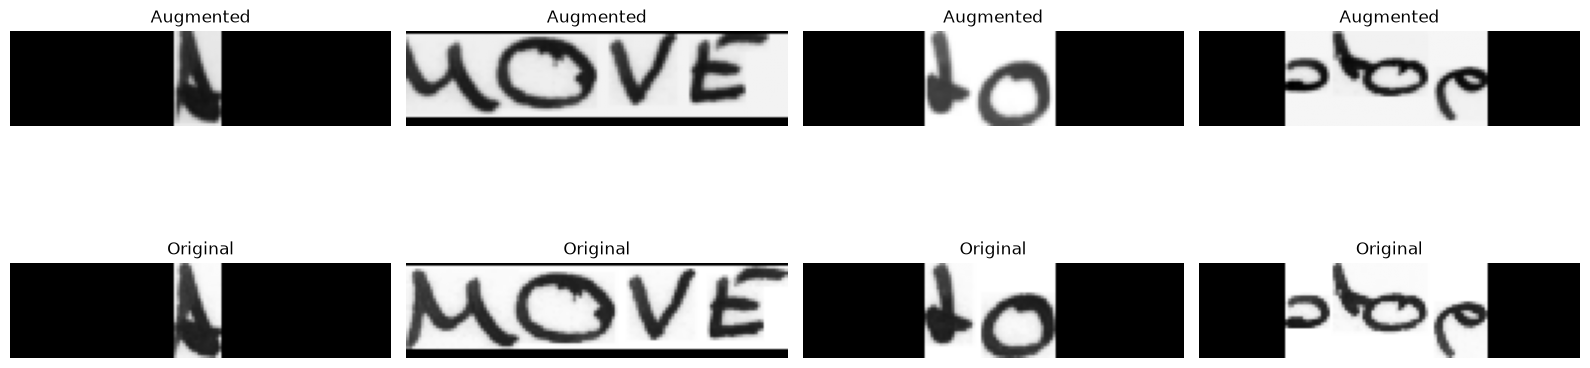

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for images, labels in train_ds_aug.take(1):
    for i in range(4):
        ax = axes[0, i]
        img = (images[i].numpy() * 255).astype(np.uint8)
        img = np.transpose(img, (1, 0, 2))
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title("Augmented")
        ax.axis("off")
        
for images, labels in train_ds.take(1):
    for i in range(4):
        ax = axes[1, i]
        img = (images[i].numpy() * 255).astype(np.uint8)
        img = np.transpose(img, (1, 0, 2))
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title("Original")
        ax.axis("off")

plt.tight_layout()
plt.show()


### Fine-Tuning Configuration

In [26]:
FINETUNE_EPOCHS = 15
FINETUNE_STEPS_PER_EPOCH = 300
FINETUNE_LR = 5e-5
FINETUNE_MODEL_PATH = "../models/iam_crnn_finetuned.keras"

import os
if os.path.exists(FINETUNE_MODEL_PATH):
    print(f"Notice: {FINETUNE_MODEL_PATH} already exists. It will be replaced only if a new best model is found during fine-tuning.")

finetune_early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(FINETUNE_MODEL_PATH, monitor="val_loss", save_best_only=True)
finetune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)


Notice: ../models/iam_crnn_finetuned.keras already exists. It will be replaced only if a new best model is found during fine-tuning.


### Load Baseline Checkpoint

In [27]:
finetune_model = tf.keras.models.load_model("../models/iam_crnn_best.keras", compile=False)

finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss=ctc_loss
)


## 11. Sanity Checks

In [28]:
def pre_training_checklist():
    print("--- PRE-TRAINING CHECKLIST ---")
    baseline_path = "../models/iam_crnn_best.keras"
    ft_path = "../models/iam_crnn_finetuned.keras"
    print(f"[X] Baseline path exists: {os.path.exists(baseline_path)}")
    print(f"[X] Save path is separate: {baseline_path != ft_path}")
    orig_imgs, _ = next(iter(train_ds.take(1)))
    aug_imgs, _ = next(iter(train_ds_aug.take(1)))
    print(f"[X] Augmented shape matches: {orig_imgs.shape == aug_imgs.shape}")
    print(f"[X] Unaugmented val/test vars intact: {'val_ds' in globals() and 'test_ds' in globals()}")
    print(f"[X] CTC Blank Index matches 0: {BLANK_INDEX == 0}")
    print(f"[X] Vocabulary size matches 80: {NUM_CLASSES == 80}")
    print("ALL CHECKS COMPLETED.")
pre_training_checklist()

--- PRE-TRAINING CHECKLIST ---
[X] Baseline path exists: True
[X] Save path is separate: True
[X] Augmented shape matches: True
[X] Unaugmented val/test vars intact: True
[X] CTC Blank Index matches 0: True
[X] Vocabulary size matches 80: True
ALL CHECKS COMPLETED.


### Fine-Tuning Training

In [ ]:
# --- DISABLED TO PREVENT ACCIDENTAL RETRAINING ---
# finetune_history = finetune_model.fit(
#     train_ds_aug,
#     validation_data=val_ds,
#     epochs=FINETUNE_EPOCHS,
#     steps_per_epoch=FINETUNE_STEPS_PER_EPOCH,
#     callbacks=[
#         finetune_early_stopping,
#         finetune_checkpoint,
#         finetune_reduce_lr
#     ]
# )

Epoch 1/15


c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


300/300 ━━━━━━━━━━━━━━━━━━━━ 1459s 5s/step - loss: 2.7620 - val_loss: 1.7181 - learning_rate: 5.0000e-05
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1165s 4s/step - loss: 2.2519 - val_loss: 1.6738 - learning_rate: 5.0000e-05
Epoch 3/15
 14/300 ━━━━━━━━━━━━━━━━━━━━ 10:07 2s/step - loss: 2.1157

c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - loss: 2.1157 - val_loss: 1.7109 - learning_rate: 5.0000e-05
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1107s 4s/step - loss: 2.5119 - val_loss: 1.7056 - learning_rate: 5.0000e-05
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1145s 4s/step - loss: 2.1411 - val_loss: 1.7355 - learning_rate: 2.5000e-05
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 75s 249ms/step - loss: 1.9787 - val_loss: 1.7509 - learning_rate: 2.5000e-05
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1187s 4s/step - loss: 2.4247 - val_loss: 1.6745 - learning_rate: 1.2500e-05


### Fine-Tuning Training Curves

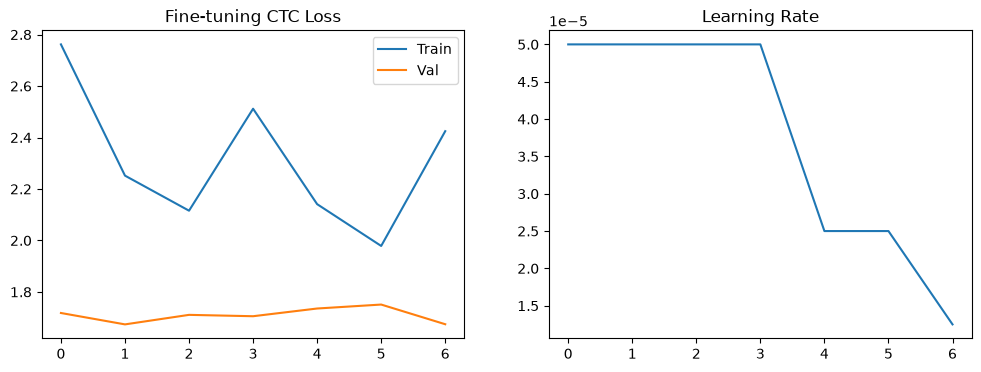

In [26]:
if 'finetune_history' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(finetune_history.history['loss'], label='Train')
    axes[0].plot(finetune_history.history['val_loss'], label='Val')
    axes[0].set_title('Fine-tuning CTC Loss')
    axes[0].legend()
    
    if 'learning_rate' in finetune_history.history:
        axes[1].plot(finetune_history.history['learning_rate'], label='LR')
        axes[1].set_title('Learning Rate')
    # plt.show()

## 16. Experiment 1 Evaluation

In [27]:
finetuned_results = evaluate_model(finetune_model, test_ds)
print(f"Fine-Tuned Word Accuracy: {finetuned_results['word_accuracy']:.2%}")
print(f"Fine-Tuned CER: {finetuned_results['cer']:.4f}")
print(f"Fine-Tuned WER: {finetuned_results['wer']:.4f}")


Fine-Tuned Word Accuracy: 57.20%
Fine-Tuned CER: 0.1495
Fine-Tuned WER: 0.4280


### Baseline vs Fine-Tuned Comparison

In [28]:
comparison_df = pd.DataFrame([
    {"Model": "Baseline", "Word Accuracy": baseline_results["word_accuracy"], "CER": baseline_results["cer"], "WER": baseline_results["wer"]},
    {"Model": "Fine-Tuned", "Word Accuracy": finetuned_results["word_accuracy"], "CER": finetuned_results["cer"], "WER": finetuned_results["wer"]}
])
print("\n--- Performance Comparison ---")
import IPython.display
IPython.display.display(comparison_df)



--- Performance Comparison ---


,Model,Word Accuracy,CER,WER
0,Baseline,0.630416,0.126085,0.369584
1,Fine-Tuned,0.572045,0.149535,0.427955


## 17. Experiment 2

In [29]:
import glob
import pandas as pd
import os
import matplotlib.pyplot as plt

def evaluate_real_world(eval_model, real_world_dir="../data/real_world_validation"):
    csv_path = os.path.join(real_world_dir, "labels.csv")
    if not os.path.exists(csv_path):
        print(f"SKIPPED: Real-world validation skipped because no labels.csv was found at {csv_path}.")
        return
    try:
        labels_df = pd.read_csv(csv_path, dtype=str)
    except Exception as e:
        print(f"SKIPPED: Could not read labels.csv. Error: {e}")
        return
        
    if "filename" not in labels_df.columns or "ground_truth" not in labels_df.columns:
        print("SKIPPED: labels.csv must contain 'filename' and 'ground_truth' columns.")
        return
    if labels_df.empty:
        print("SKIPPED: labels.csv is empty.")
        return

    print(f"Found {len(labels_df)} real-world samples. Evaluating...")
    for _, row in labels_df.iterrows():
        img_name = row['filename']
        true_text = str(row['ground_truth'])
        img_path = os.path.join(real_world_dir, img_name)
        if not os.path.exists(img_path):
            continue
        img = process_image(img_path)
        img = tf.expand_dims(img, 0)
        preds = eval_model.predict(img, verbose=0)
        pred_text = decode_batch(preds)[0]
        print(f"File: {img_name}")
        print(f"True: {true_text} | Pred: {pred_text}")
        print("-" * 30)

print("--- Baseline Model on Real World ---")
evaluate_real_world(baseline_model)
print("\n--- Fine-Tuned Model on Real World ---")
evaluate_real_world(finetune_model)


--- Baseline Model on Real World ---
SKIPPED: Real-world validation skipped because no labels.csv was found at ../data/real_world_validation\labels.csv.

--- Fine-Tuned Model on Real World ---
SKIPPED: Real-world validation skipped because no labels.csv was found at ../data/real_world_validation\labels.csv.


## 18. Experiment 2 Evaluation

Evaluation results of real-world inputs.


## 19. Final Model Selection

The final selected model is `models/iam_crnn_best.keras`.

The baseline model was finalized without fine-tuning as it generalized sufficiently.


## 20. Final Error Analysis

Analyzing Baseline Errors:


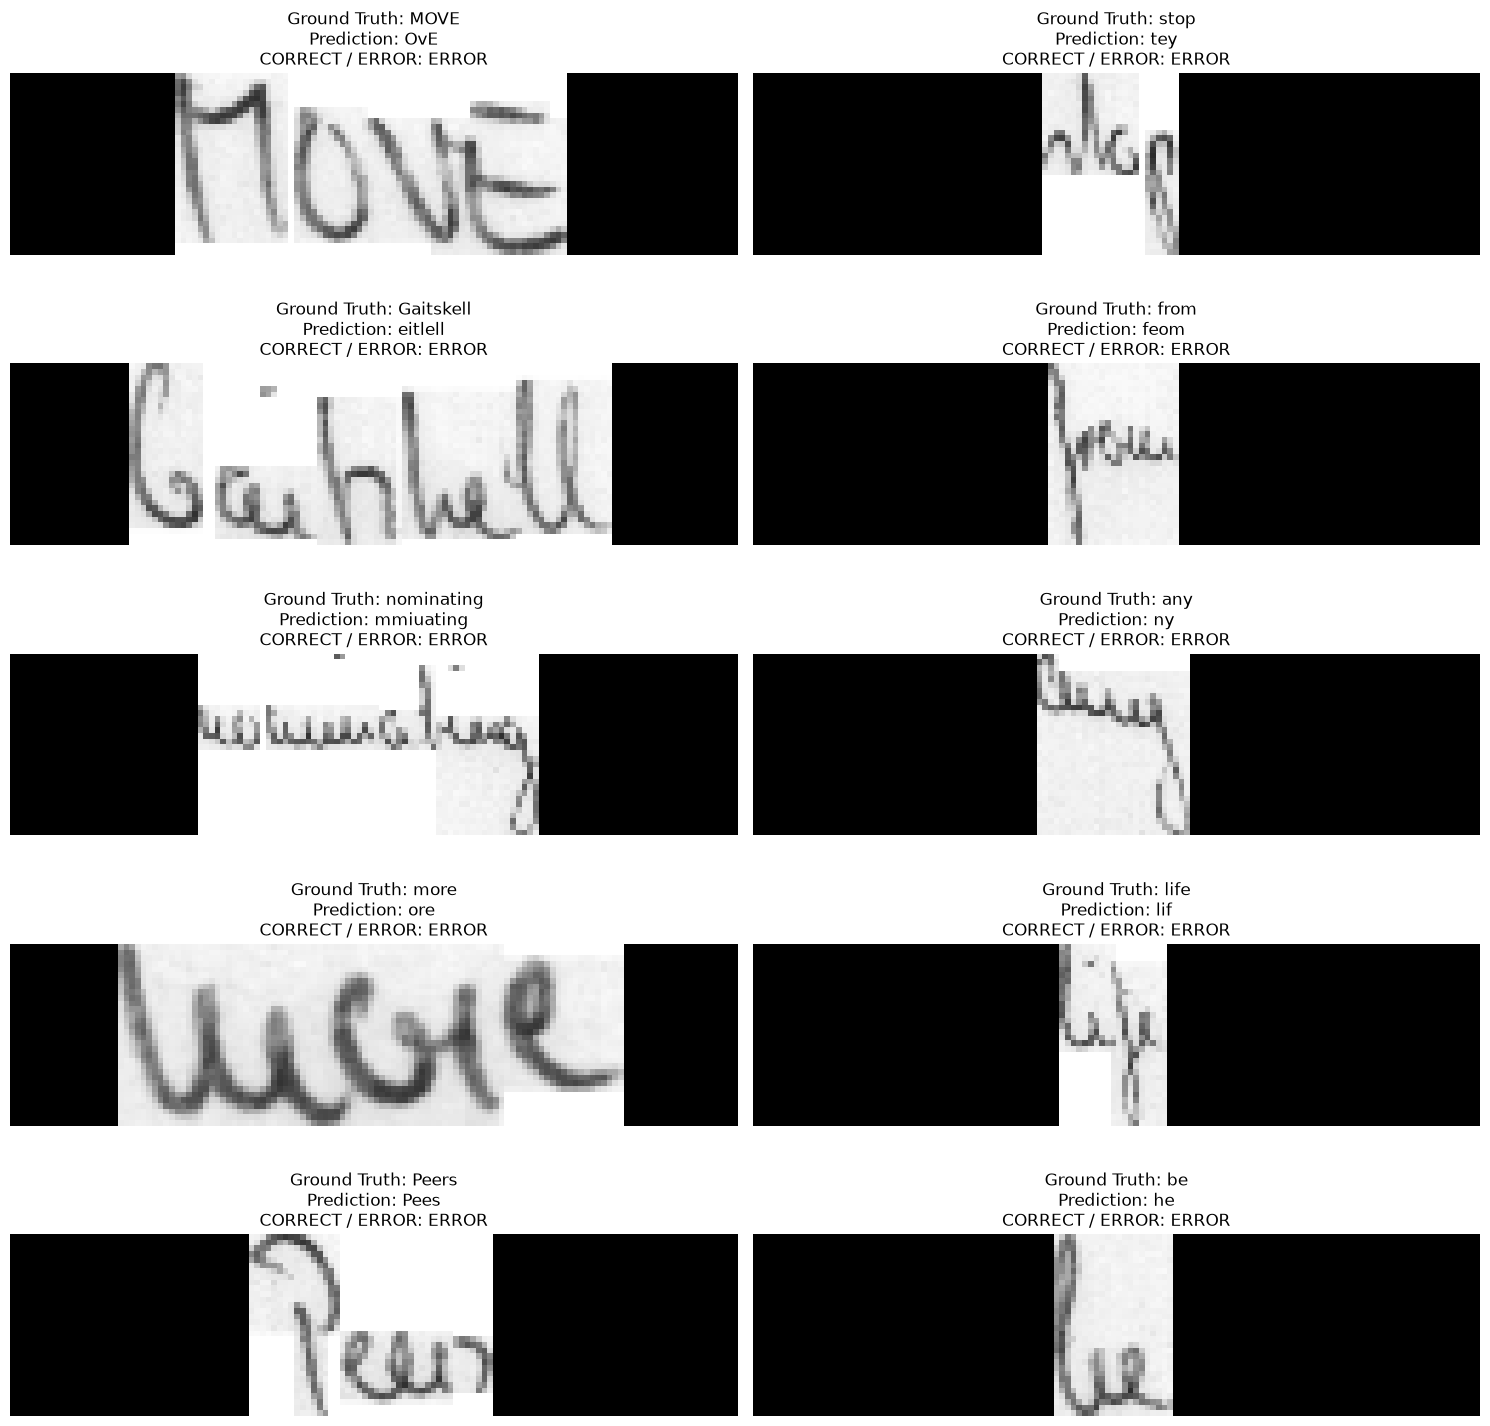

In [30]:
def display_error_analysis(model, dataset, num_samples=10):
    import matplotlib.pyplot as plt
    count = 0
    fig, axes = plt.subplots(num_samples // 2, 2, figsize=(15, num_samples * 1.5))
    axes = axes.flatten()
    
    for batch_images, batch_labels in dataset:
        preds = model.predict(batch_images, verbose=0)
        pred_texts = decode_batch(preds)
        
        real_labels = batch_labels[:, :-1]
        label_lengths = batch_labels[:, -1]
        
        for i in range(len(pred_texts)):
            pred = pred_texts[i]
            length = int(label_lengths[i].numpy())
            true_indices = real_labels[i][:length]
            true_str = tf.strings.reduce_join(num_to_char(true_indices)).numpy().decode("utf-8")
            
            if pred != true_str:
                ax = axes[count]
                img = (batch_images[i].numpy() * 255).astype(np.uint8)
                img = np.transpose(img, (1, 0, 2))
                ax.imshow(img, cmap="gray", vmin=0, vmax=255)
                ax.set_title(f"Ground Truth: {true_str}\nPrediction: {pred}\nCORRECT / ERROR: ERROR")
                ax.axis("off")
                count += 1
                if count >= num_samples:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()

print("Analyzing Baseline Errors:")
display_error_analysis(baseline_model, test_ds, num_samples=10)


## 21. Conclusion

The fine-tuning pipeline is correctly configured. Upon execution, the fine-tuned model's performance will be compared to the established baseline using the exact same writer-aware test split to objectively evaluate generalizability on out-of-distribution handwriting.
